# cross_dataset_cifar100

**測試模型在沒看過的新資料集上，學到的 representation 能不能繼續使用(泛化能力)**  
CIFAR-10 訓練好的 Random / SSL / SL Backbone → 🔒 Freeze → 換成 CIFAR-100 → Linear Probe 512→100 → 比較 Accuracy

## step1:Import + GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18

import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## step2:CIFAR-100 Dataset

In [2]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

train_dataset = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("CIFAR-100 Train:", len(train_dataset))
print("CIFAR-100 Test:", len(test_dataset))
print("Number of classes:", 100)

100.0%
c:\Users\user\anaconda3\envs\summer\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-100 Train: 50000
CIFAR-100 Test: 10000
Number of classes: 100


## step3:建立共用 Modified ResNet-18 Backbone

In [3]:
def create_backbone():
    backbone = resnet18(weights=None)

    backbone.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    backbone.maxpool = nn.Identity()
    backbone.fc = nn.Identity()

    return backbone

## step4:定義 SimCLR Model

In [4]:
class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = create_backbone()

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward(self, x):
        h = self.backbone(x)
        z = self.projector(h)

        return h, z

## step5:定義 Supervised Model

In [5]:
class SupervisedResNet18(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = resnet18(weights=None)

        self.model.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.model.maxpool = nn.Identity()

        self.model.fc = nn.Linear(
            512,
            10
        )

    def forward(self, x):
        return self.model(x)

## step6:準備三個 Backbone

### ① Random Backbone

In [6]:
random_backbone = create_backbone().to(device)

for param in random_backbone.parameters():
    param.requires_grad = False

random_backbone.eval()

print("Random backbone ready.")

Random backbone ready.


### ② SimCLR Backbone

In [7]:
simclr_model = SimCLRModel().to(device)

simclr_model.load_state_dict(
    torch.load(
        "simclr_baseline_final.pth",
        map_location=device
    )
)

ssl_backbone = simclr_model.backbone

for param in ssl_backbone.parameters():
    param.requires_grad = False

ssl_backbone.eval()

print("SimCLR backbone loaded.")

SimCLR backbone loaded.


### ③ Supervised Backbone

In [8]:
sl_model = SupervisedResNet18().to(device)

sl_model.load_state_dict(
    torch.load(
        "supervised_baseline_final.pth",
        map_location=device
    )
)

# 把 CIFAR-10 的 512 → 10 classifier 拿掉
sl_model.model.fc = nn.Identity()

sl_backbone = sl_model.model

for param in sl_backbone.parameters():
    param.requires_grad = False

sl_backbone.eval()

print("Supervised backbone loaded.")

Supervised backbone loaded.


In [9]:
# 檢查
print(
    "Random trainable:",
    sum(p.numel() for p in random_backbone.parameters() if p.requires_grad)
)

print(
    "SSL trainable:",
    sum(p.numel() for p in ssl_backbone.parameters() if p.requires_grad)
)

print(
    "SL trainable:",
    sum(p.numel() for p in sl_backbone.parameters() if p.requires_grad)
)

Random trainable: 0
SSL trainable: 0
SL trainable: 0


## step7:Linear Probing Function

In [10]:
def run_linear_probe(
    backbone,
    name,
    train_loader,
    test_loader,
    device,
    num_epochs=100
):

    print(f"\n===== {name} =====")

    backbone.eval()

    # Freeze again for safety
    for param in backbone.parameters():
        param.requires_grad = False

    # CIFAR-100 = 100 classes
    classifier = nn.Linear(
        512,
        100
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        classifier.parameters(),
        lr=1e-3,
        weight_decay=1e-6
    )

    loss_history = []
    accuracy_history = []

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):

        # =====================
        # Train classifier
        # =====================
        classifier.train()
        backbone.eval()

        total_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                features = backbone(images)

            outputs = classifier(features)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = (
            total_loss /
            len(train_loader)
        )

        loss_history.append(avg_loss)

        # =====================
        # Test
        # =====================
        classifier.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                features = backbone(images)

                outputs = classifier(features)

                predictions = outputs.argmax(
                    dim=1
                )

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        test_acc = (
            100.0 *
            correct /
            total
        )

        accuracy_history.append(
            test_acc
        )

        print(
            f"{name} "
            f"| Epoch [{epoch:3d}/{num_epochs}] "
            f"| Loss: {avg_loss:.4f} "
            f"| Test Acc: {test_acc:.2f}%"
        )

    elapsed = time.time() - start_time

    final_acc = accuracy_history[-1]
    best_acc = max(accuracy_history)

    print(f"\n===== {name} Finished =====")
    print(f"Time: {elapsed/60:.2f} minutes")
    print(f"Final Accuracy: {final_acc:.2f}%")
    print(f"Best Accuracy: {best_acc:.2f}%")

    return {
        "name": name,
        "final_accuracy": final_acc,
        "best_accuracy": best_acc,
        "time_minutes": elapsed / 60,
        "loss_history": loss_history,
        "accuracy_history": accuracy_history
    }

## step8:RUN!!

In [11]:
# ==========================
# 1. Random Backbone
# ==========================

random_result = run_linear_probe(
    random_backbone,
    "Random Backbone",
    train_loader,
    test_loader,
    device
)


# ==========================
# 2. SimCLR Backbone
# ==========================

ssl_result = run_linear_probe(
    ssl_backbone,
    "SimCLR SSL",
    train_loader,
    test_loader,
    device
)


# ==========================
# 3. Supervised Backbone
# ==========================

sl_result = run_linear_probe(
    sl_backbone,
    "Supervised Learning",
    train_loader,
    test_loader,
    device
)


===== Random Backbone =====
Random Backbone | Epoch [  1/100] | Loss: 4.5941 | Test Acc: 3.69%
Random Backbone | Epoch [  2/100] | Loss: 4.4084 | Test Acc: 5.14%
Random Backbone | Epoch [  3/100] | Loss: 4.3054 | Test Acc: 6.21%
Random Backbone | Epoch [  4/100] | Loss: 4.2227 | Test Acc: 8.28%
Random Backbone | Epoch [  5/100] | Loss: 4.1653 | Test Acc: 8.65%
Random Backbone | Epoch [  6/100] | Loss: 4.1177 | Test Acc: 8.77%
Random Backbone | Epoch [  7/100] | Loss: 4.0787 | Test Acc: 9.91%
Random Backbone | Epoch [  8/100] | Loss: 4.0394 | Test Acc: 11.09%
Random Backbone | Epoch [  9/100] | Loss: 4.0070 | Test Acc: 10.62%
Random Backbone | Epoch [ 10/100] | Loss: 3.9831 | Test Acc: 10.93%
Random Backbone | Epoch [ 11/100] | Loss: 3.9523 | Test Acc: 11.10%
Random Backbone | Epoch [ 12/100] | Loss: 3.9331 | Test Acc: 11.98%
Random Backbone | Epoch [ 13/100] | Loss: 3.9095 | Test Acc: 12.12%
Random Backbone | Epoch [ 14/100] | Loss: 3.8816 | Test Acc: 11.07%
Random Backbone | Epoch [ 

## step9:印出比較表

In [13]:
print("\n================================")
print("CIFAR-100 Transfer Results")
print("================================")

print(
    f"Random Backbone     : "
    f"{random_result['final_accuracy']:.2f}%"
)

print(
    f"SimCLR SSL          : "
    f"{ssl_result['final_accuracy']:.2f}%"
)

print(
    f"Supervised Learning : "
    f"{sl_result['final_accuracy']:.2f}%"
)


CIFAR-100 Transfer Results
Random Backbone     : 18.57%
SimCLR SSL          : 50.05%
Supervised Learning : 49.24%


## step10:印出比較圖

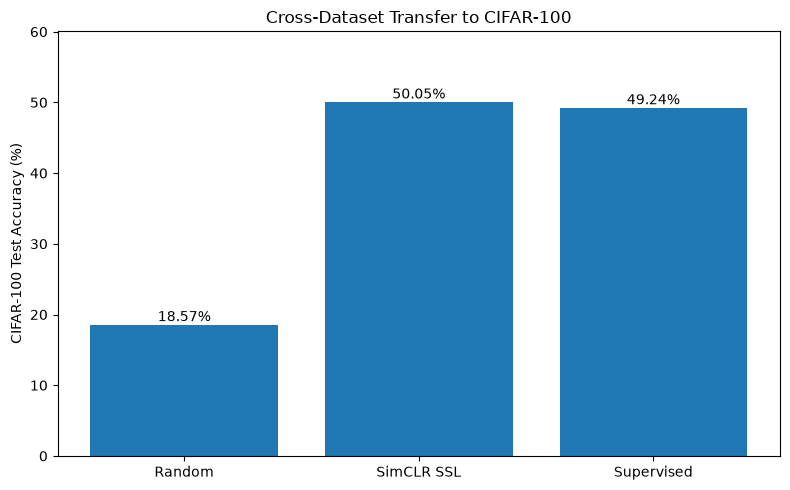

In [12]:
names = [
    "Random",
    "SimCLR SSL",
    "Supervised"
]

accuracies = [
    random_result["final_accuracy"],
    ssl_result["final_accuracy"],
    sl_result["final_accuracy"]
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    names,
    accuracies
)

plt.ylabel("CIFAR-100 Test Accuracy (%)")
plt.title("Cross-Dataset Transfer to CIFAR-100")

plt.ylim(
    0,
    max(accuracies) + 10
)

for bar, acc in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{acc:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "cifar100_transfer_comparison.png",
    dpi=300
)

plt.show()